<a href="https://colab.research.google.com/github/tanviupadhyay1517/Hypothesis-Testing-/blob/main/Paired_t_test_Insulin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Case Study:**
The insulin pump is a device that delivers insulin to a diabetic patient at regular intervals. It presumably regulates insulin better than standard injections. However, data to establish this point are few, especially in children. The following study was set up to assess the effect of use of the insulin pump on HgbA1c, which is a long-term marker of compliance with insulin protocols. (HbA1c) test measures the amount of blood sugar (glucose) attached to hemoglobin. In general, a normal range for HgbA1c is < 7%. Data were collected on 256 diabetic patients for 1 year before and after using the insulin pump. A subset of the data for 10 diabetic patients given. Which test can be used to compare the mean HgbA1c 1 year before vs. mean HgbA1c 1 year after use of the insulin pump? (The data is available in Insulin.xlsx)

In [1]:
# Import necessary packages
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Read data
df1 = pd.read_excel('/content/drive/MyDrive/Classroom/FTN Batch 10/T test Two sample/Insulin.xlsx')

# Exploratory Analysis

In [4]:
df1.columns

Index(['ID', 'before', 'after'], dtype='object')

In [5]:
df1.head()                                  # Viewing first few observations of the data

,ID,before,after
0,1,6.7,7.0
1,2,7.4,7.4
2,3,9.2,8.6
3,4,9.6,8.1
4,5,7.4,6.8


In [6]:
df1.describe()                              # Descriptive statistics

,ID,before,after
count,10.00000,10.000000,10.000000
mean,5.50000,8.500000,7.850000
std,3.02765,1.506283,0.898455
min,1.00000,6.700000,6.800000
25%,3.25000,7.400000,7.100000
50%,5.50000,8.000000,7.700000
75%,7.75000,9.500000,8.400000
max,10.00000,10.800000,9.700000


In [7]:
# Taking difference
df1['errors_diff'] = df1['before'] - df1['after']
df1['errors_diff'].describe()

,errors_diff
count,10.000000
mean,0.650000
std,1.435464
min,-1.800000
25%,-0.225000
50%,0.600000
75%,1.400000
max,3.100000


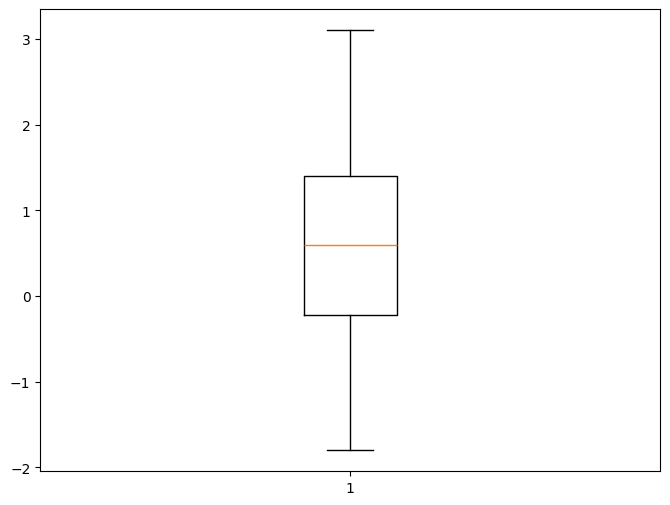

In [8]:
# Boxplot
plt.figure(figsize=(8, 6))
plt.boxplot(df1['errors_diff'])
plt.show()

In [9]:
# Checking Normality using Shapiro test
Shapiro1=stats.shapiro(df1['errors_diff'])
Shapiro1

ShapiroResult(statistic=np.float64(0.9906047805975086), pvalue=np.float64(0.9974902878954712))

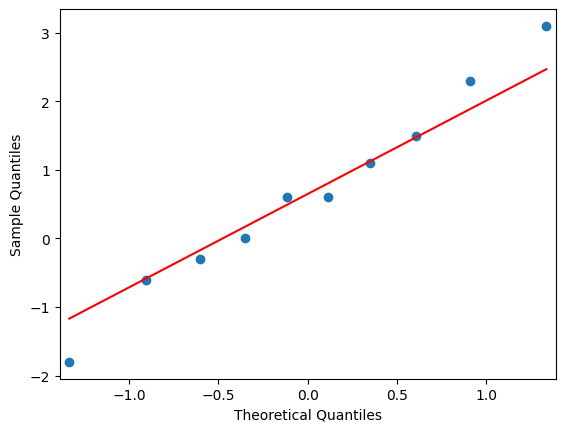

In [10]:
# Checking Normality using Q-Q plot
from statsmodels.graphics.gofplots import qqplot
from matplotlib import pyplot

qqplot(df1['errors_diff'],line='s')
plt.show()

In [12]:
# Paired t test / t test for dependent samples

ttest=stats.ttest_rel(df1['before'] , df1['after'], alternative ='two-sided')
ttest

TtestResult(statistic=np.float64(1.4319280367391265), pvalue=np.float64(0.18596367848456666), df=np.int64(9))

In [13]:
print("Average errors before training:", df1['before'].mean())
print("Average errors after training :", df1['after'].mean())

Average errors before training: 8.5
Average errors after training : 7.85
